# Imports

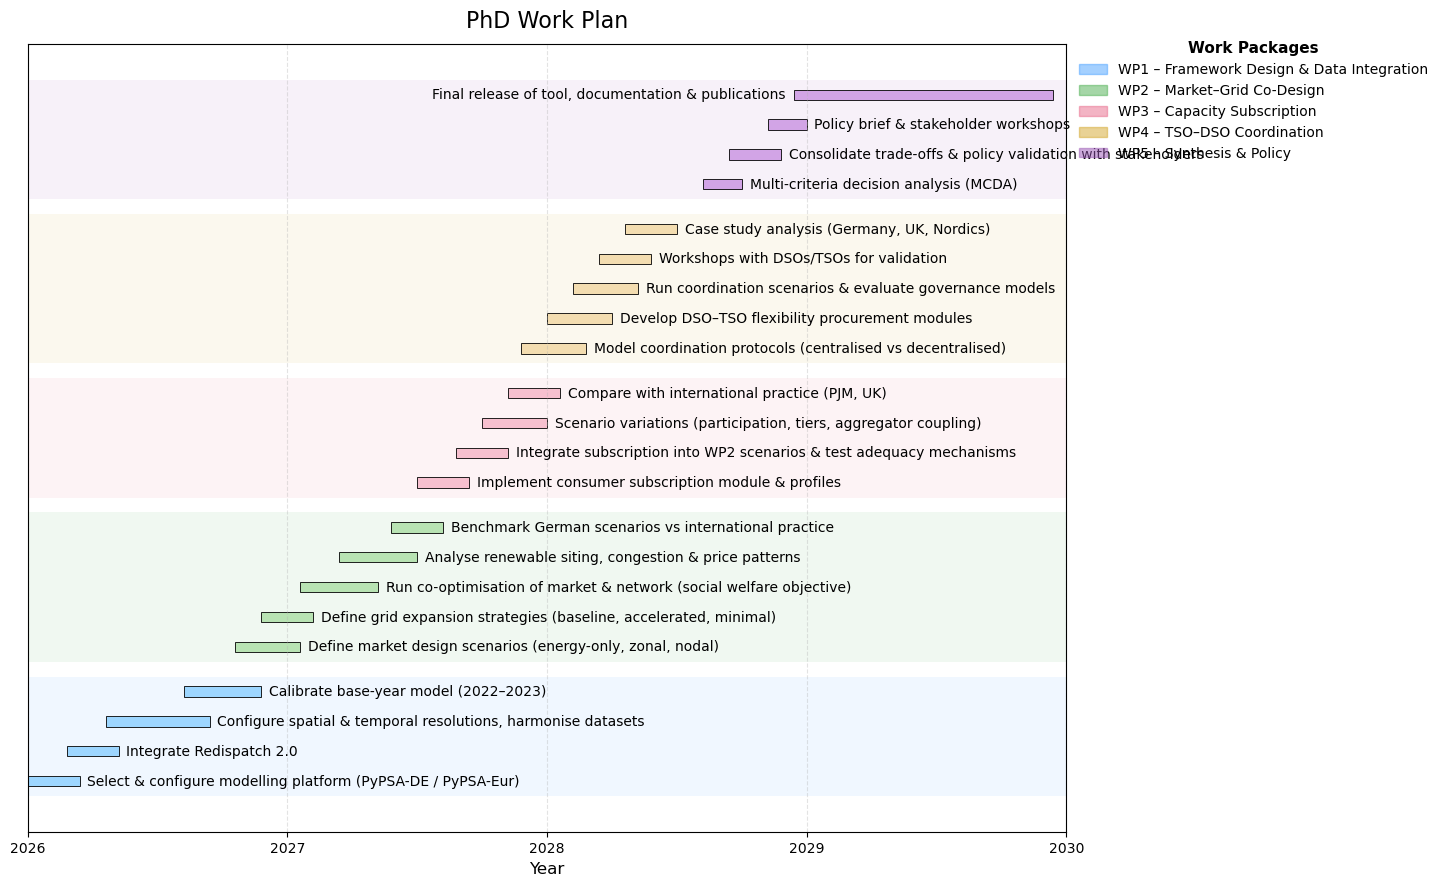

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import defaultdict

# ---------------- data (same as yours) ----------------
tasks = [
    # WP1 – Framework Design & Data Integration
    ("WP1 – Framework Design & Data Integration", "Select & configure modelling platform (PyPSA-DE / PyPSA-Eur)", 2026.00, 2026.20, '#9dd6ff'),
    ("WP1 – Framework Design & Data Integration", "Integrate Redispatch 2.0", 2026.15, 2026.35, '#9dd6ff'),
    ("WP1 – Framework Design & Data Integration", "Configure spatial & temporal resolutions, harmonise datasets", 2026.30, 2026.70, '#9dd6ff'),
    ("WP1 – Framework Design & Data Integration", "Calibrate base-year model (2022–2023)", 2026.60, 2026.90, '#9dd6ff'),

    # WP2 – Co-Design of Market Mechanisms & Grid Planning
    ("WP2 – Market–Grid Co-Design", "Define market design scenarios (energy-only, zonal, nodal)", 2026.80, 2027.05, '#b8e3b3'),
    ("WP2 – Market–Grid Co-Design", "Define grid expansion strategies (baseline, accelerated, minimal)", 2026.90, 2027.10, '#b8e3b3'),
    ("WP2 – Market–Grid Co-Design", "Run co-optimisation of market & network (social welfare objective)", 2027.05, 2027.35, '#b8e3b3'),
    ("WP2 – Market–Grid Co-Design", "Analyse renewable siting, congestion & price patterns", 2027.20, 2027.50, '#b8e3b3'),
    ("WP2 – Market–Grid Co-Design", "Benchmark German scenarios vs international practice", 2027.40, 2027.60, '#b8e3b3'),

    # WP3 – Capacity Subscription & Adequacy Mechanisms
    ("WP3 – Capacity Subscription", "Implement consumer subscription module & profiles", 2027.50, 2027.70, '#f7c0cf'),
    ("WP3 – Capacity Subscription", "Integrate subscription into WP2 scenarios & test adequacy mechanisms", 2027.65, 2027.85, '#f7c0cf'),
    ("WP3 – Capacity Subscription", "Scenario variations (participation, tiers, aggregator coupling)", 2027.75, 2028.00, '#f7c0cf'),
    ("WP3 – Capacity Subscription", "Compare with international practice (PJM, UK)", 2027.85, 2028.05, '#f7c0cf'),

    # WP4 – TSO–DSO Coordination & International Insights
    ("WP4 – TSO–DSO Coordination", "Model coordination protocols (centralised vs decentralised)", 2027.90, 2028.15, '#f3ddb0'),
    ("WP4 – TSO–DSO Coordination", "Develop DSO–TSO flexibility procurement modules", 2028.00, 2028.25, '#f3ddb0'),
    ("WP4 – TSO–DSO Coordination", "Run coordination scenarios & evaluate governance models", 2028.10, 2028.35, '#f3ddb0'),
    ("WP4 – TSO–DSO Coordination", "Workshops with DSOs/TSOs for validation", 2028.20, 2028.40, '#f3ddb0'),
    ("WP4 – TSO–DSO Coordination", "Case study analysis (Germany, UK, Nordics)", 2028.30, 2028.50, '#f3ddb0'),

    # WP5 – Synthesis & Policy Recommendations
    ("WP5 – Synthesis & Policy", "Multi-criteria decision analysis (MCDA)", 2028.60, 2028.75, '#d2a4e6'),
    ("WP5 – Synthesis & Policy", "Consolidate trade-offs & policy validation with stakeholders", 2028.70, 2028.90, '#d2a4e6'),
    ("WP5 – Synthesis & Policy", "Policy brief & stakeholder workshops", 2028.85, 2029.00, '#d2a4e6'),
    ("WP5 – Synthesis & Policy", "Final release of tool, documentation & publications", 2028.95, 2029.95, '#d2a4e6'),
]



# ---------------- layout helpers ----------------
tasks = sorted(tasks, key=lambda t: (t[2], t[3]))

# y positions with small gaps per WP
ys, wp_bounds, wp_colors = [], {}, {
    "WP1 – Framework Design & Data Integration": "#4aa3ff",
    "WP2 – Market–Grid Co-Design": "#4caf50",
    "WP3 – Capacity Subscription": "#e86a8b",
    "WP4 – TSO–DSO Coordination": "#d4a72c",
    "WP5 – Synthesis & Policy": "#9b59b6",
}
gap = 0.5
y = 0.0
last_wp = None
for wp, *_ in tasks:
    if wp != last_wp and last_wp is not None:
        y += gap
    ys.append(y); y += 1.0; last_wp = wp

# compute WP vertical bands
band_alpha = 0.08
for (wp, *_), yval in zip(tasks, ys):
    if wp not in wp_bounds:
        wp_bounds[wp] = [yval - 0.5, None]
    wp_bounds[wp][1] = yval + 0.5

# ---------------- plot ----------------
fig, ax = plt.subplots(figsize=(14.5, 9))
ax.set_facecolor("white")

# background bands
for wp, (y0, y1) in wp_bounds.items():
    ax.axhspan(y0, y1, color=wp_colors[wp], alpha=band_alpha, linewidth=0)

# bars + smart labels
RIGHT_PAD = 0.03
LEFT_PAD  = 0.03
SWITCH_YEAR = 2029.0   # anything ending after this prints label on the LEFT

for (wp, label, start, end, color), y in zip(tasks, ys):
    ax.barh(y, end - start, left=start, height=0.35, color=color,
            edgecolor="black", linewidth=0.6)

    # left/right label rule
    place_left = (end > SWITCH_YEAR) or (wp.startswith("WP5") and label.startswith("Final"))
    if place_left:
        ax.text(start - LEFT_PAD, y, label, va="center", ha="right", fontsize=10, clip_on=False)
    else:
        ax.text(end + RIGHT_PAD, y, label, va="center", ha="left",  fontsize=10, clip_on=False)

# legend pushed well outside so it never collides
patches = [mpatches.Patch(color=wp_colors[w], label=w, alpha=0.5) for w in wp_bounds]
leg = ax.legend(handles=patches, title="Work Packages", frameon=False, fontsize=10,
                bbox_to_anchor=(1.0, 1.02), loc="upper left")
leg.get_title().set_fontsize(11); leg.get_title().set_fontweight("bold")

# axes + grid
ax.set_yticks([])
ax.set_xlim(2026, 2030)
ax.set_xticks([2026, 2027, 2028, 2029, 2030])
ax.set_xlabel("Year", fontsize=12)
ax.set_title("PhD Work Plan", fontsize=16, pad=12)
ax.grid(axis='x', linestyle='--', alpha=0.35)

# more right margin for labels; legend sits even further right
plt.tight_layout(pad=1.2)
plt.subplots_adjust(right=0.74)
plt.show()


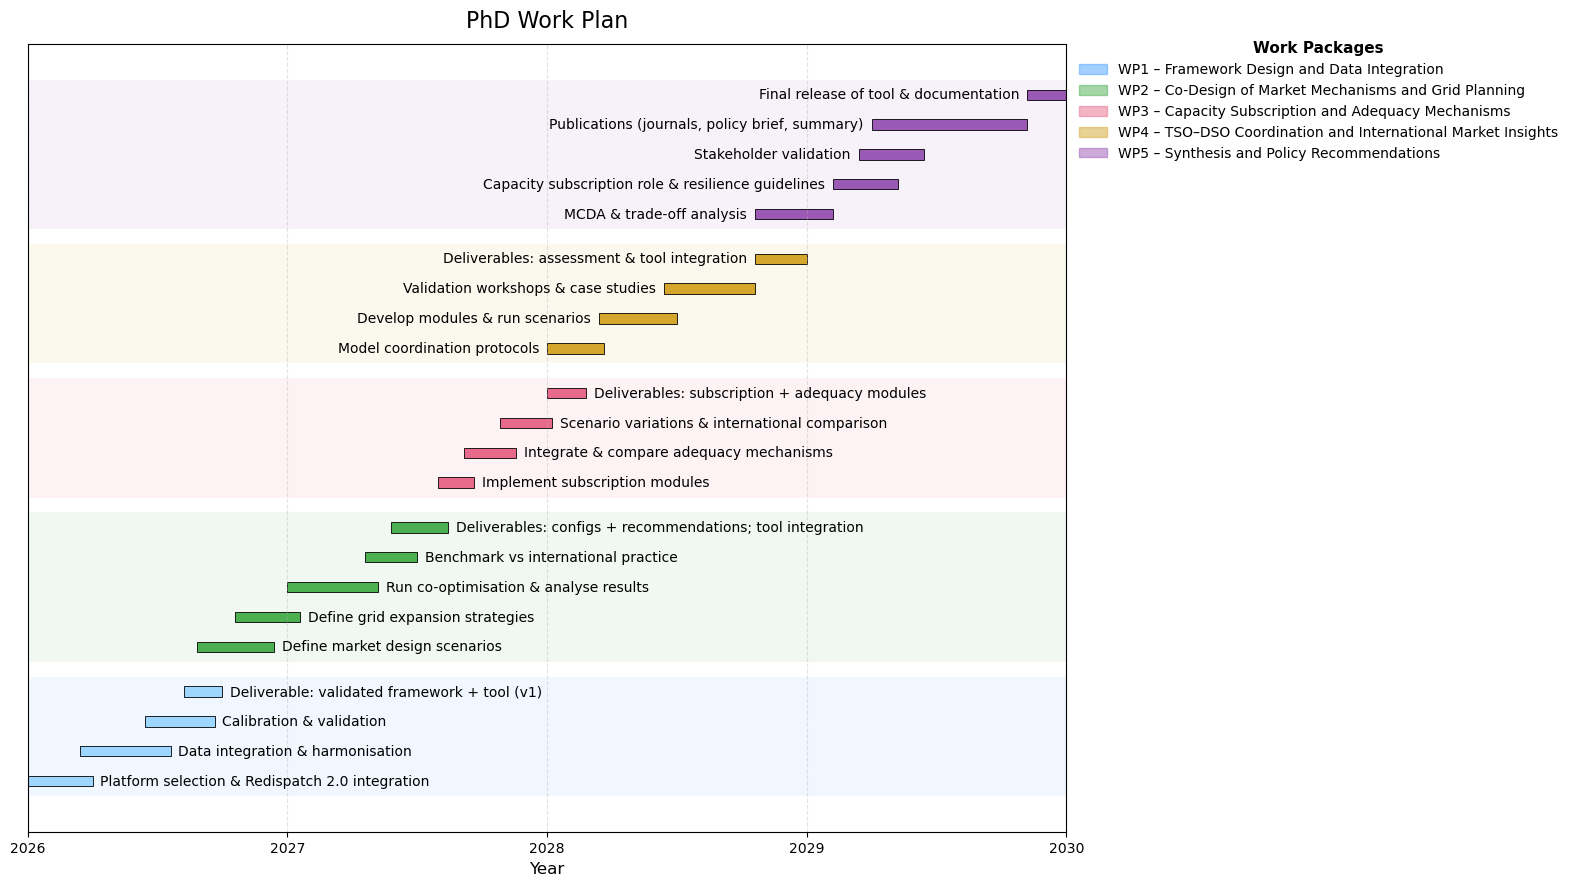

In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import defaultdict

tasks = [
    # WP1 – Framework Design and Data Integration (2026)
    ("WP1 – Framework Design and Data Integration", "Platform selection & Redispatch 2.0 integration", 2026.00, 2026.25, '#9dd6ff'),
    ("WP1 – Framework Design and Data Integration", "Data integration & harmonisation",                 2026.20, 2026.55, '#9dd6ff'),
    ("WP1 – Framework Design and Data Integration", "Calibration & validation",                         2026.45, 2026.72, '#9dd6ff'),
    ("WP1 – Framework Design and Data Integration", "Deliverable: validated framework + tool (v1)",     2026.60, 2026.75, '#9dd6ff'),

    # WP2 – Co-Design of Market Mechanisms and Grid Planning (late 2026–2027)
    ("WP2 – Co-Design of Market Mechanisms and Grid Planning", "Define market design scenarios",                  2026.65, 2026.95, '#4caf50'),
    ("WP2 – Co-Design of Market Mechanisms and Grid Planning", "Define grid expansion strategies",                2026.80, 2027.05, '#4caf50'),
    ("WP2 – Co-Design of Market Mechanisms and Grid Planning", "Run co-optimisation & analyse results",           2027.00, 2027.35, '#4caf50'),
    ("WP2 – Co-Design of Market Mechanisms and Grid Planning", "Benchmark vs international practice",             2027.30, 2027.50, '#4caf50'),
    # gentle overlap into WP3 (handover window)
    ("WP2 – Co-Design of Market Mechanisms and Grid Planning", "Deliverables: configs + recommendations; tool integration",
                                                                                                                   2027.40, 2027.62, '#4caf50'),

    # WP3 – Capacity Subscription and Adequacy Mechanisms (2027–2028) — starts slightly before WP2 fully ends
    ("WP3 – Capacity Subscription and Adequacy Mechanisms", "Implement subscription modules",                     2027.58, 2027.72, '#e86a8b'),
    ("WP3 – Capacity Subscription and Adequacy Mechanisms", "Integrate & compare adequacy mechanisms",            2027.68, 2027.88, '#e86a8b'),
    ("WP3 – Capacity Subscription and Adequacy Mechanisms", "Scenario variations & international comparison",     2027.82, 2028.02, '#e86a8b'),
    # small overlap with WP4 setup is fine (coordination built on WP3 insights)
    ("WP3 – Capacity Subscription and Adequacy Mechanisms", "Deliverables: subscription + adequacy modules",      2028.00, 2028.15, '#e86a8b'),

    # WP4 – TSO–DSO Coordination and International Market Insights (2028–2029)
    ("WP4 – TSO–DSO Coordination and International Market Insights", "Model coordination protocols",               2028.00, 2028.22, '#d4a72c'),
    ("WP4 – TSO–DSO Coordination and International Market Insights", "Develop modules & run scenarios",            2028.20, 2028.50, '#d4a72c'),
    ("WP4 – TSO–DSO Coordination and International Market Insights", "Validation workshops & case studies",        2028.45, 2028.80, '#d4a72c'),
    ("WP4 – TSO–DSO Coordination and International Market Insights", "Deliverables: assessment & tool integration",2028.80, 2029.00, '#d4a72c'),

    # WP5 – Synthesis and Policy Recommendations (late 2028–2030) — overlaps with late WP4 for synthesis ramp-up
    ("WP5 – Synthesis and Policy Recommendations", "MCDA & trade-off analysis",                                   2028.80, 2029.10, '#9b59b6'),
    ("WP5 – Synthesis and Policy Recommendations", "Capacity subscription role & resilience guidelines",           2029.10, 2029.35, '#9b59b6'),
    ("WP5 – Synthesis and Policy Recommendations", "Stakeholder validation",                                       2029.20, 2029.45, '#9b59b6'),
    ("WP5 – Synthesis and Policy Recommendations", "Publications (journals, policy brief, summary)",               2029.25, 2029.85, '#9b59b6'),
    ("WP5 – Synthesis and Policy Recommendations", "Final release of tool & documentation",                        2029.85, 2030.00, '#9b59b6'),
]




# --------- layout helpers ----------
tasks = sorted(tasks, key=lambda t: (t[2], t[3]))

ys, wp_bounds = [], {}
wp_colors = {
    "WP1 – Framework Design and Data Integration": "#4aa3ff",
    "WP2 – Co-Design of Market Mechanisms and Grid Planning": "#4caf50",
    "WP3 – Capacity Subscription and Adequacy Mechanisms": "#e86a8b",
    "WP4 – TSO–DSO Coordination and International Market Insights": "#d4a72c",
    "WP5 – Synthesis and Policy Recommendations": "#9b59b6",
}
gap = 0.5
y = 0.0
last_wp = None
for wp, *_ in tasks:
    if wp != last_wp and last_wp is not None:
        y += gap
    ys.append(y); y += 1.0; last_wp = wp

band_alpha = 0.08
for (wp, *_), yval in zip(tasks, ys):
    if wp not in wp_bounds:
        wp_bounds[wp] = [yval - 0.5, None]
    wp_bounds[wp][1] = yval + 0.5

# --------- plot ----------
fig, ax = plt.subplots(figsize=(14.5, 9))
ax.set_facecolor("white")

# background bands
for wp, (y0, y1) in wp_bounds.items():
    ax.axhspan(y0, y1, color=wp_colors[wp], alpha=band_alpha, linewidth=0)

RIGHT_PAD = 0.03
LEFT_PAD  = 0.03
SWITCH_YEAR = 2029.0

for (wp, label, start, end, color), y in zip(tasks, ys):
    ax.barh(y, end - start, left=start, height=0.35, color=color,
            edgecolor="black", linewidth=0.6)

    # place all WP4 and WP5 labels on the LEFT; others use year-based rule
    is_wp4 = wp.startswith("WP4 – TSO–DSO Coordination and International Market Insights")
    is_wp5 = wp.startswith("WP5 – Synthesis and Policy Recommendations")
    place_left = is_wp4 or is_wp5 or (end > SWITCH_YEAR)

    if place_left:
        ax.text(start - LEFT_PAD, y, label, va="center", ha="right", fontsize=10, clip_on=False)
    else:
        ax.text(end + RIGHT_PAD, y, label, va="center", ha="left",  fontsize=10, clip_on=False)

# legend
patches = [mpatches.Patch(color=wp_colors[w], label=w, alpha=0.5) for w in wp_bounds]
leg = ax.legend(handles=patches, title="Work Packages", frameon=False, fontsize=10,
                bbox_to_anchor=(1.0, 1.02), loc="upper left")
leg.get_title().set_fontsize(11); leg.get_title().set_fontweight("bold")

# axes + grid
ax.set_yticks([])
ax.set_xlim(2026, 2030)
ax.set_xticks([2026, 2027, 2028, 2029, 2030])
ax.set_xlabel("Year", fontsize=12)
ax.set_title("PhD Work Plan", fontsize=16, pad=12)
ax.grid(axis='x', linestyle='--', alpha=0.35)

plt.tight_layout(pad=1.2)
plt.subplots_adjust(right=0.74)
plt.show()


In [9]:
import os
import warnings
import random
import pypsa
import xarray as xr
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy
import cartopy.crs as ccrs
import cartopy.feature

# Functions

In [10]:
# Color config
config = {
    "plotting": {
        "tech_colors": {
            "solar": "gold",
            "onwind": "skyblue",
            "offwind": "steelblue",
            "gas": "grey",
            "coal": "black",
            "nuclear": "purple",
            "biomass": "green",
        },
        "nice_names": {
            "solar": "solar",
            "onwind": "onwind",
            "offwind": "offwind",
            "gas": "gas",
            "coal": "coal",
            "nuclear": "nuclear",
            "biomass": "biomass",
        }
    }
}

# Legend helper functions
def add_legend_circles(ax, sizes, labels, legend_kw=None):
    from matplotlib.legend_handler import HandlerPatch
    import matplotlib.patches as mpatches
    handles = [mpatches.Circle((0, 0), radius=s) for s in sizes]
    ax.legend(handles, labels, handler_map={mpatches.Circle: HandlerPatch()}, **(legend_kw or {}))

def add_legend_lines(ax, widths, labels, legend_kw=None):
    import matplotlib.lines as mlines
    handles = [mlines.Line2D([], [], color='teal', linewidth=w) for w in widths]
    ax.legend(handles, labels, **(legend_kw or {}))

def add_legend_patches(ax, colors, labels, legend_kw=None):
    import matplotlib.patches as mpatches
    handles = [mpatches.Patch(color=c) for c in colors]
    ax.legend(handles, labels, **(legend_kw or {}))

# Color matching for pie charts
def color_matching(stats):
    colors = {key.lower(): value.lower() for key, value in config["plotting"]["tech_colors"].items()}
    nice_names = {value.lower(): key for key, value in config["plotting"]["nice_names"].items()}
    color_list = []
    for carrier in stats.index.get_level_values("carrier"):
        original_name = carrier.lower()
        key_name = nice_names.get(original_name, original_name)
        color = colors.get(key_name.lower(), 'gray')
        color_list.append(color)
    return color_list

# Voronoi plotting function
def plot_voronoi(n, carrier, voronoi, cmap, projection, title=None, filename=None, country_coordinates=None):
    """
    Plot potential density (MW/km²) for a given carrier using Voronoi regions.
    """
    try:
        # Load Voronoi regions GeoJSON
        br = gpd.read_file(f"resources/bus_regions/regions_{voronoi}.geojson").set_index("name")
        br_area = br.to_crs("ESRI:54009")
        area_km2 = br_area.geometry.area * 1e-6

        # Prepare generator data
        g = n.generators[n.generators.carrier == carrier].copy()

        if g.empty:
            print(f"No generators found for carrier {carrier}. Skipping Voronoi plot.")
            return

        # Extract region id from bus names
        g["region_id"] = g["bus"].str.split().str[-1]
        grouped = g.groupby("region_id").p_nom_max.sum()

        # Reindex to match br regions
        br["p_nom_max"] = grouped.reindex(br.index).fillna(0) / area_km2.values

        print(f"\nVoronoi p_nom_max density for {carrier}:")
        print(br["p_nom_max"])

        fig, ax = plt.subplots(figsize=(8, 4), subplot_kw={"projection": projection})
        plt.rcParams.update({"font.size": 10})
        br.plot(
            ax=ax,
            column="p_nom_max",
            transform=ccrs.PlateCarree(),
            linewidth=0.25,
            edgecolor="k",
            cmap=cmap,
            vmin=0,
            vmax=br["p_nom_max"].max(),
            legend=True,
            legend_kwds={"label": "Potential Density [MW/km²]"},
        )
        ax.coastlines()
        ax.add_feature(cartopy.feature.BORDERS.with_scale("110m"))
        if country_coordinates is not None:
            ax.set_extent(country_coordinates, crs=ccrs.PlateCarree())

        if title is not None:
            plt.title(title)

        if filename is not None:
            plt.savefig(filename, bbox_inches="tight", dpi=300)
            plt.close()
        else:
            plt.show()

    except Exception as e:
        print(f"Could not plot Voronoi for {carrier}: {e}")

# Files

In [11]:
countries = gpd.read_file("resources/shapes/country_shapes.geojson")
country_coordinates = countries.total_bounds

regions_onshore = gpd.GeoDataFrame(
    geometry=gpd.points_from_xy([0], [0]),
    crs="EPSG:4326"
).buffer(5).to_frame(name='geometry')

solar = xr.open_dataset("resources/renewable_profiles/profile_solar.nc")
wind = xr.open_dataset("resources/renewable_profiles/profile_onwind.nc")

folder = "results/postnetworks/"

C:\Users\ffill\AppData\Local\Temp\ipykernel_20772\1316940101.py:7: UserWarning:

Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.




# Plots


=== Processing file: elec_s_105_ec_lcopt_Co2L0.3-1h_1h_2030_0.05_ASEAN_0export.nc ===


INFO:pypsa.network.io:New version 0.35.2 available! (Current: 0.35.1)
Index(['CO2 pipeline BN5 0 <-> MY5 0-2030',
       'CO2 pipeline ID16 0 <-> ID16 2-2030',
       'CO2 pipeline ID16 1 <-> ID16 2-2030',
       'CO2 pipeline ID17 0 <-> ID17 2-2030',
       'CO2 pipeline ID17 1 <-> ID17 2-2030',
       'CO2 pipeline ID17 1 <-> ID19 1-2030',
       'CO2 pipeline ID18 0 <-> ID18 1-2030',
       'CO2 pipeline ID18 0 <-> ID18 2-2030',
       'CO2 pipeline ID19 0 <-> ID19 2-2030',
       'CO2 pipeline ID19 1 <-> ID19 2-2030',
       ...
       'TH12 0 urban central solid biomass CHP CC-2030',
       'TH14 0 urban central solid biomass CHP CC-2030',
       'TH14 1 urban central solid biomass CHP CC-2030',
       'TH35 0 urban central solid biomass CHP CC-2030',
       'VN0 0 urban central solid biomass CHP CC-2030',
       'VN0 1 urban central solid biomass CHP CC-2030',
       'VN0 2 urban central solid biomass CHP CC-2030',
       'VN0 3 urban central solid biomass CHP CC-2030',
       'V

Network loaded from results/postnetworks/elec_s_105_ec_lcopt_Co2L0.3-1h_1h_2030_0.05_ASEAN_0export.nc
Name: 
Meta: {'foresight': 'myopic', 'countries': ['SG', 'KH', 'BN', 'PH', 'ID', 'TH', 'VN', 'MM', 'MY', 'LA'], 'enable': {'retrieve_databundle': False, 'retrieve_databundle_sector': False, 'retrieve_cost_data': False, 'download_osm_data': False, 'build_natura_raster': False, 'build_cutout': False, 'progress_bar': True}, 'scenario': {'ll': ['copt'], 'clusters': [105], 'planning_horizons': [2030, 2035], 'demand': ['ASEAN'], 'opts': ['Co2L0.3-1h'], 'sopts': ['1h'], 'simpl': [''], 'unc': ['m0', 'm1', 'm2', 'm3', 'm4', 'm5', 'm6', 'm7', 'm8']}, 'snapshots': {'start': '2018-01-01', 'end': '2018-02-01', 'inclusive': 'left'}, 'cluster_options': {'simplify_network': {'remove_stubs': False, 'remove_stubs_across_borders': False, 'p_threshold_drop_isolated': 0, 'p_threshold_merge_isolated': 0, 's_threshold_fetch_isolated': 0.1, 'to_substations': False, 'algorithm': 'kmeans', 'feature': 'solar+onw

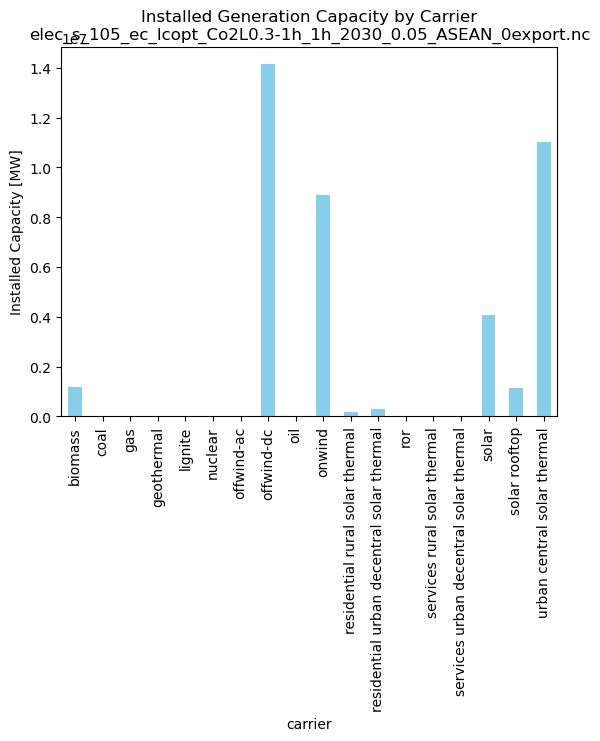

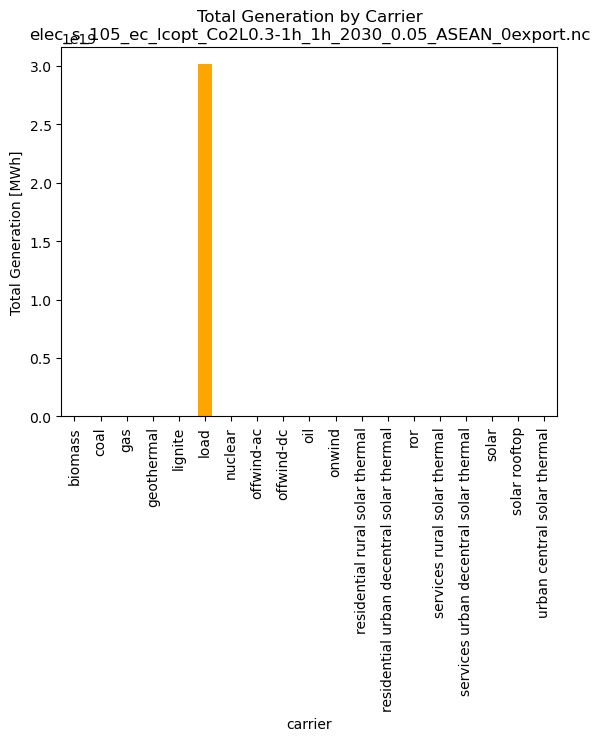

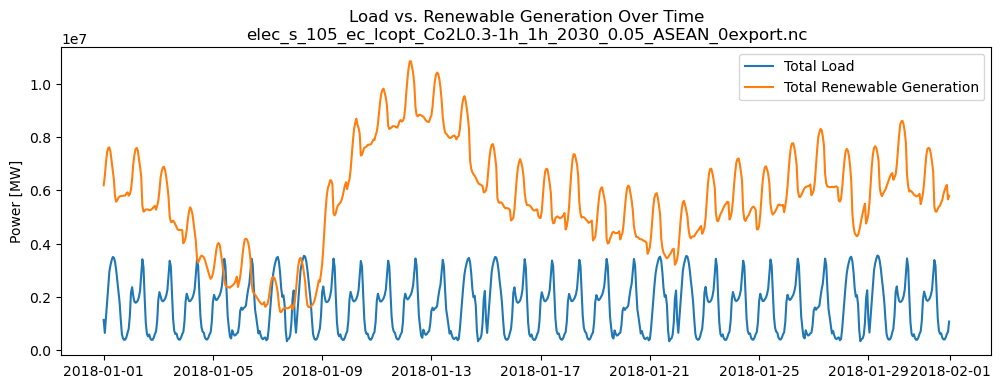

C:\Users\ffill\AppData\Local\Temp\ipykernel_20772\4106607889.py:78: DeprecatedWarning:

plot is deprecated as of 0.34 and will be removed in 1.0. Use `n.plot.map()` as a drop-in replacement instead.



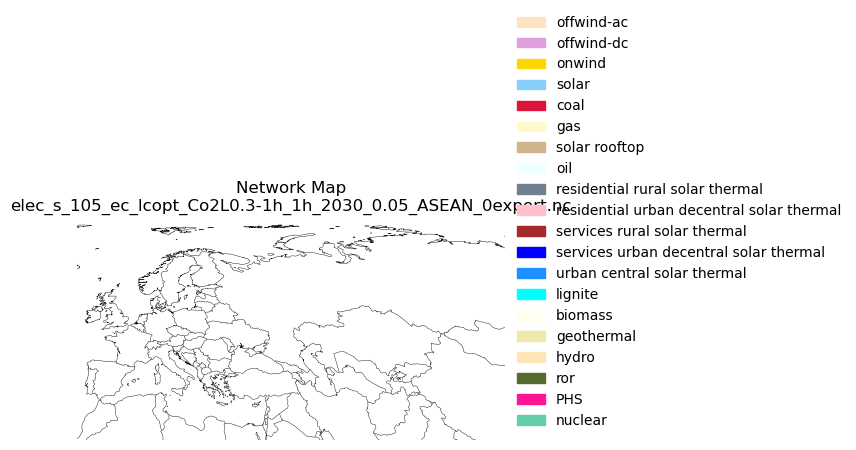


Generator capacity by carrier (GW):
carrier
biomass                                       0.000000
coal                                          0.000000
gas                                           0.000000
geothermal                                    5.507000
lignite                                       0.000000
nuclear                                       0.621000
offwind-ac                                    0.000000
offwind-dc                                    1.103799
oil                                           0.000000
onwind                                       13.572563
residential rural solar thermal               0.000000
residential urban decentral solar thermal     0.000000
ror                                          12.227470
services rural solar thermal                  0.000000
services urban decentral solar thermal        0.000000
solar                                        50.995732
solar rooftop                                 0.000000
urban central solar 

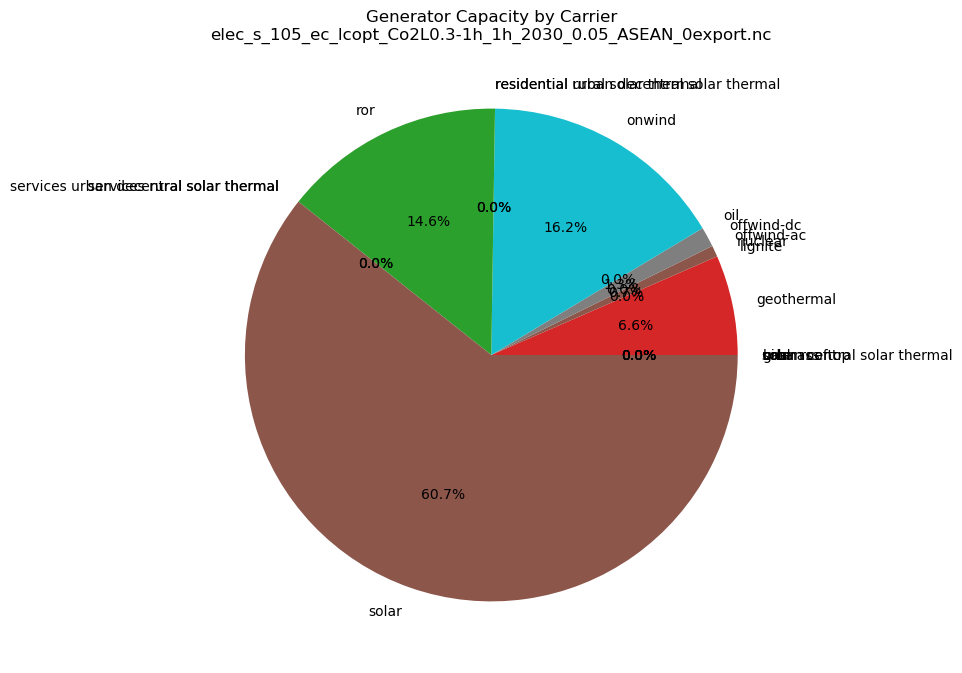


Cross-border links:
                             bus0 country1 carrier        p_nom    p_nom_opt
Link                                                                        
5233                       TH10 0       MY      DC   491.400000   491.400367
5248                       TH10 0       MY      DC   491.400000   491.400367
Plentong - Woodlands        MY0 1       SG      DC   525.000000  1049.999997
Telok Gong – Perawang       MY0 1       ID      DC   600.000000  1199.999995
Kudat – Palawan             MY4 0       PH      DC   196.000000   391.999995
...                           ...      ...     ...          ...          ...
KH0 0 coal-2025        KH0 0 coal       KH    coal  1106.060606  1106.060606
LA0 1 coal-2025        LA0 1 coal       LA    coal  2000.000000  2000.000000
PH1 1 coal-2025        PH1 1 coal       PH    coal  5866.666667  5866.666667
VN0 1 coal-2025        VN0 1 coal       VN    coal  3636.363636  3636.363636
VN0 2 coal-2025        VN0 2 coal       VN    coal  433

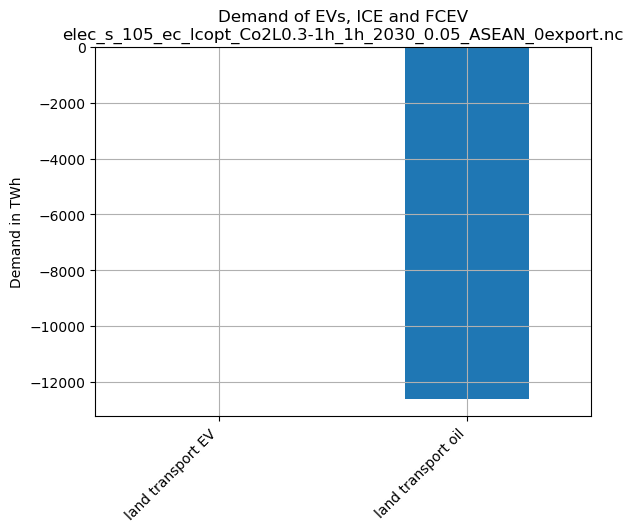

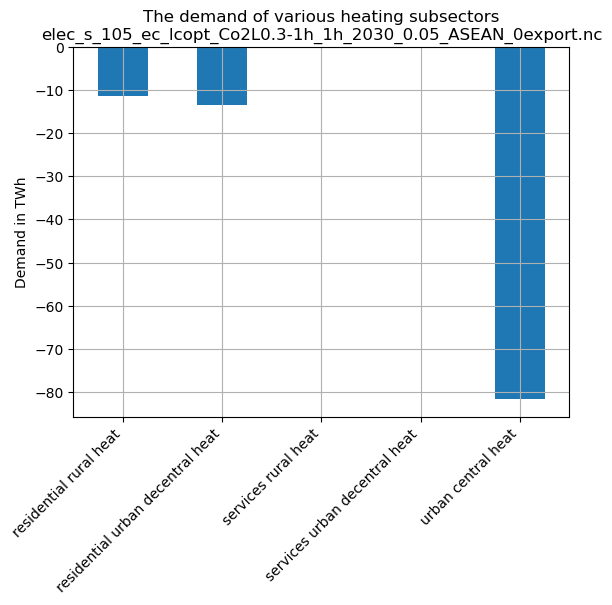

Gas Boiler: 32.70231 MWh
Heat Pump: 2263877.68288 MWh
Resistive Heater: 32.7969 MWh
CHP: 10309506514.98354 MWh


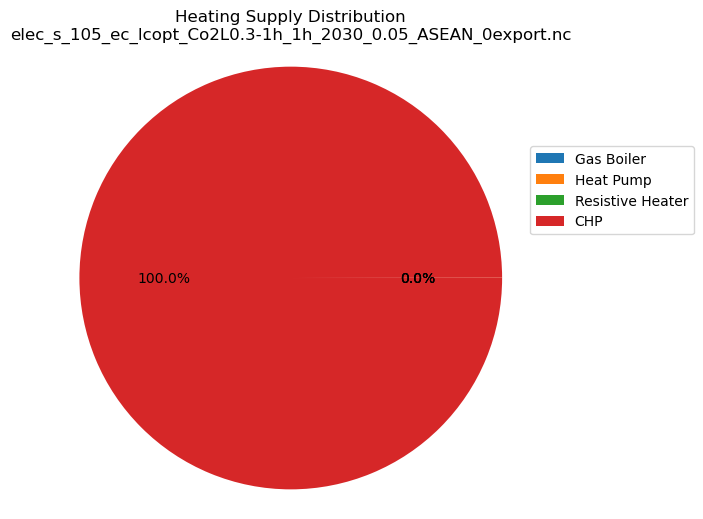

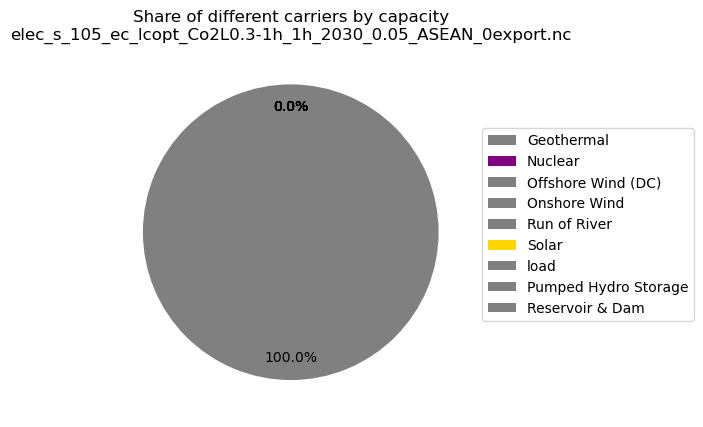

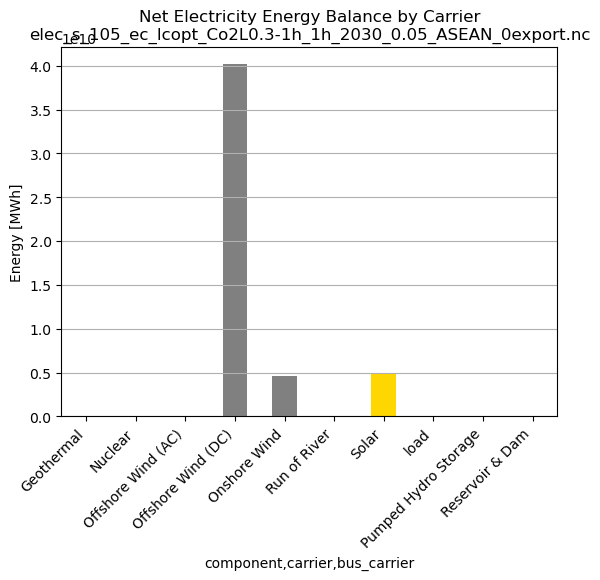


Voronoi p_nom_max density for onwind:
name
1341    0.0
1369    0.0
1518    0.0
1520    0.0
1657    0.0
       ... 
3859    0.0
3860    0.0
3861    0.0
3862    0.0
3863    0.0
Name: p_nom_max, Length: 3018, dtype: float64


c:\Users\ffill\anaconda3\envs\pypsa-earth-plus\lib\site-packages\matplotlib\colors.py:1254: RuntimeWarning:

invalid value encountered in divide

c:\Users\ffill\anaconda3\envs\pypsa-earth-plus\lib\site-packages\matplotlib\colors.py:1254: RuntimeWarning:

invalid value encountered in divide



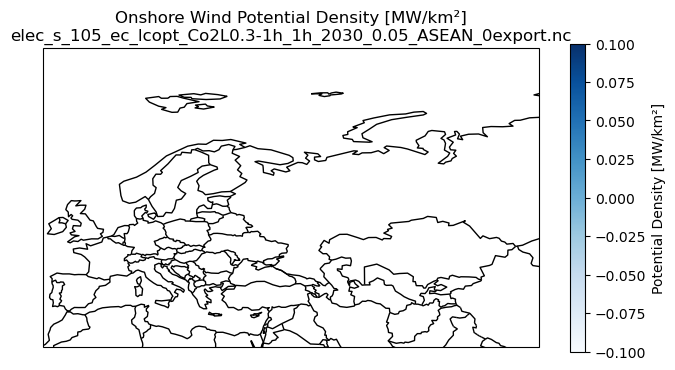


Voronoi p_nom_max density for solar:
name
1341    0.0
1369    0.0
1518    0.0
1520    0.0
1657    0.0
       ... 
3859    0.0
3860    0.0
3861    0.0
3862    0.0
3863    0.0
Name: p_nom_max, Length: 3018, dtype: float64


c:\Users\ffill\anaconda3\envs\pypsa-earth-plus\lib\site-packages\matplotlib\colors.py:1254: RuntimeWarning:

invalid value encountered in divide

c:\Users\ffill\anaconda3\envs\pypsa-earth-plus\lib\site-packages\matplotlib\colors.py:1254: RuntimeWarning:

invalid value encountered in divide



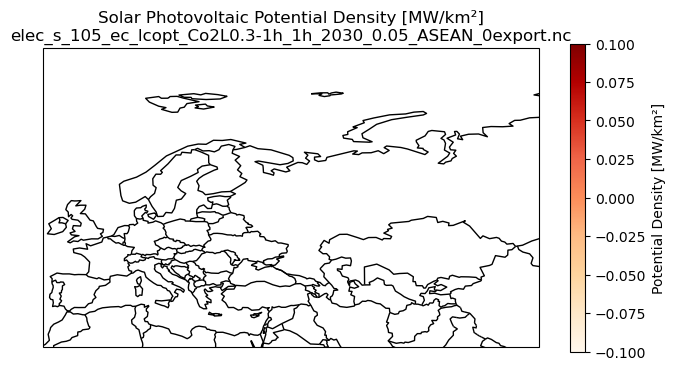


=== Processing file: elec_s_105_ec_lcopt_Co2L0.3-1h_1h_2035_0.05_ASEAN_0export.nc ===


INFO:pypsa.network.io:New version 0.35.2 available! (Current: 0.35.1)
Index(['CO2 pipeline BN5 0 <-> MY5 0-2035',
       'CO2 pipeline ID16 0 <-> ID16 2-2035',
       'CO2 pipeline ID16 1 <-> ID16 2-2035',
       'CO2 pipeline ID17 0 <-> ID17 2-2035',
       'CO2 pipeline ID17 1 <-> ID17 2-2035',
       'CO2 pipeline ID17 1 <-> ID19 1-2035',
       'CO2 pipeline ID18 0 <-> ID18 1-2035',
       'CO2 pipeline ID18 0 <-> ID18 2-2035',
       'CO2 pipeline ID19 0 <-> ID19 2-2035',
       'CO2 pipeline ID19 1 <-> ID19 2-2035',
       ...
       'TH12 0 urban central solid biomass CHP CC-2030',
       'TH14 0 urban central solid biomass CHP CC-2030',
       'TH14 1 urban central solid biomass CHP CC-2030',
       'TH35 0 urban central solid biomass CHP CC-2030',
       'VN0 0 urban central solid biomass CHP CC-2030',
       'VN0 1 urban central solid biomass CHP CC-2030',
       'VN0 2 urban central solid biomass CHP CC-2030',
       'VN0 3 urban central solid biomass CHP CC-2030',
       'V

Network loaded from results/postnetworks/elec_s_105_ec_lcopt_Co2L0.3-1h_1h_2035_0.05_ASEAN_0export.nc
Name: 
Meta: {'foresight': 'myopic', 'countries': ['SG', 'KH', 'BN', 'PH', 'ID', 'TH', 'VN', 'MM', 'MY', 'LA'], 'enable': {'retrieve_databundle': False, 'retrieve_databundle_sector': False, 'retrieve_cost_data': False, 'download_osm_data': False, 'build_natura_raster': False, 'build_cutout': False, 'progress_bar': True}, 'scenario': {'ll': ['copt'], 'clusters': [105], 'planning_horizons': [2030, 2035], 'demand': ['ASEAN'], 'opts': ['Co2L0.3-1h'], 'sopts': ['1h'], 'simpl': [''], 'unc': ['m0', 'm1', 'm2', 'm3', 'm4', 'm5', 'm6', 'm7', 'm8']}, 'snapshots': {'start': '2018-01-01', 'end': '2018-02-01', 'inclusive': 'left'}, 'cluster_options': {'simplify_network': {'remove_stubs': False, 'remove_stubs_across_borders': False, 'p_threshold_drop_isolated': 0, 'p_threshold_merge_isolated': 0, 's_threshold_fetch_isolated': 0.1, 'to_substations': False, 'algorithm': 'kmeans', 'feature': 'solar+onw

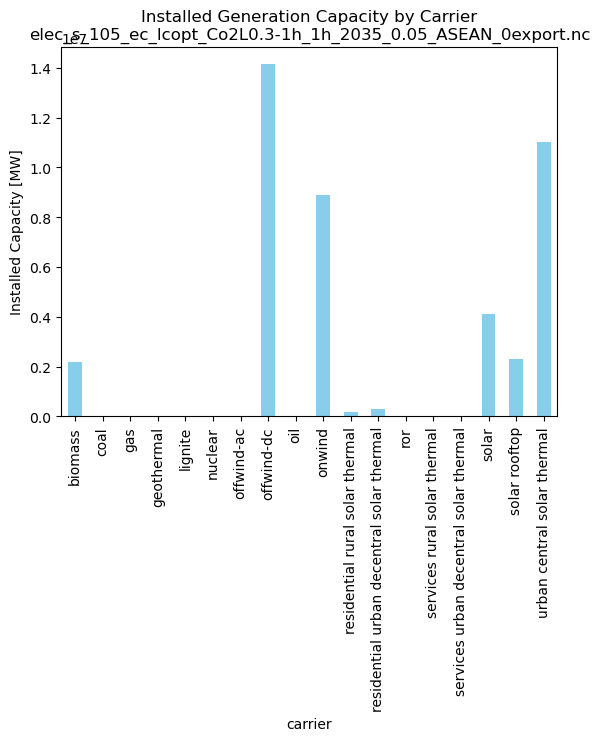

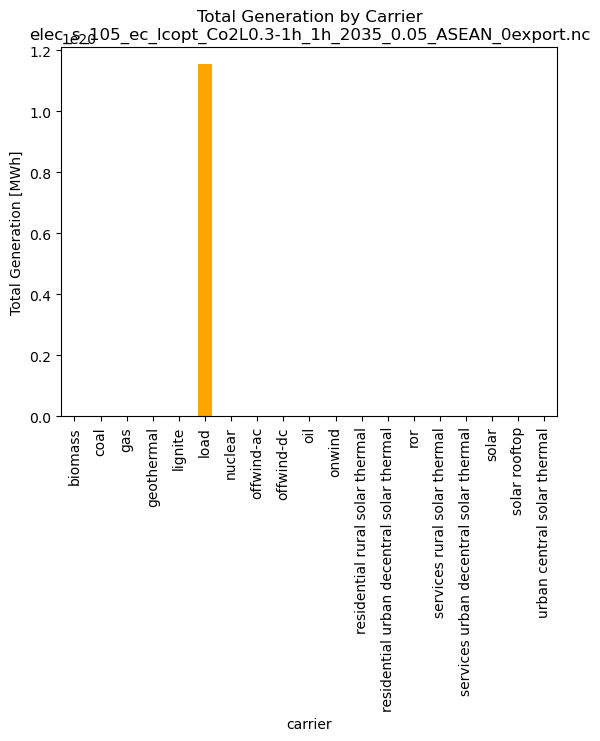

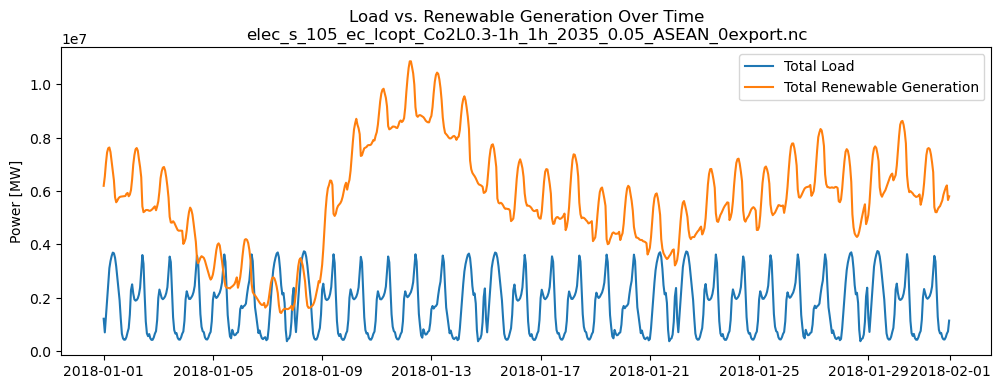

C:\Users\ffill\AppData\Local\Temp\ipykernel_20772\4106607889.py:78: DeprecatedWarning:

plot is deprecated as of 0.34 and will be removed in 1.0. Use `n.plot.map()` as a drop-in replacement instead.



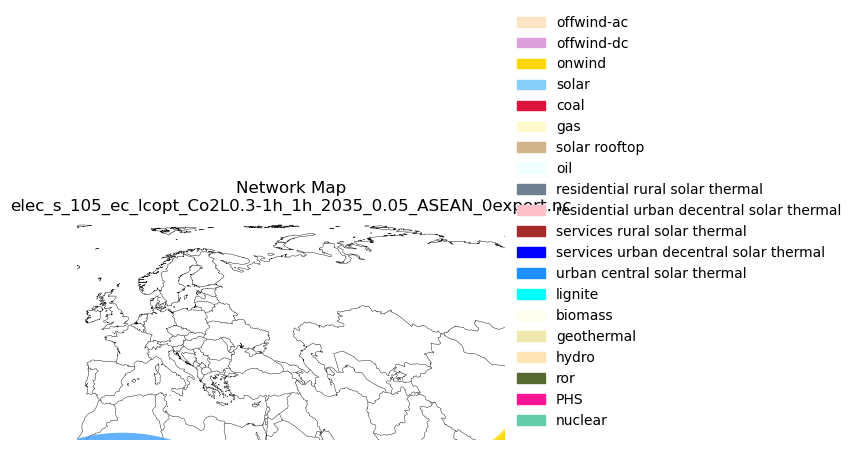


Generator capacity by carrier (GW):
carrier
biomass                                          0.000000
coal                                             0.000000
gas                                              0.000000
geothermal                                       5.507000
lignite                                          0.000000
nuclear                                          0.621000
offwind-ac                                       3.902933
offwind-dc                                   14138.344052
oil                                              0.000000
onwind                                        8899.047528
residential rural solar thermal                188.502311
residential urban decentral solar thermal      281.284342
ror                                             12.227470
services rural solar thermal                     0.390261
services urban decentral solar thermal           1.323094
solar                                         4115.085311
solar rooftop              

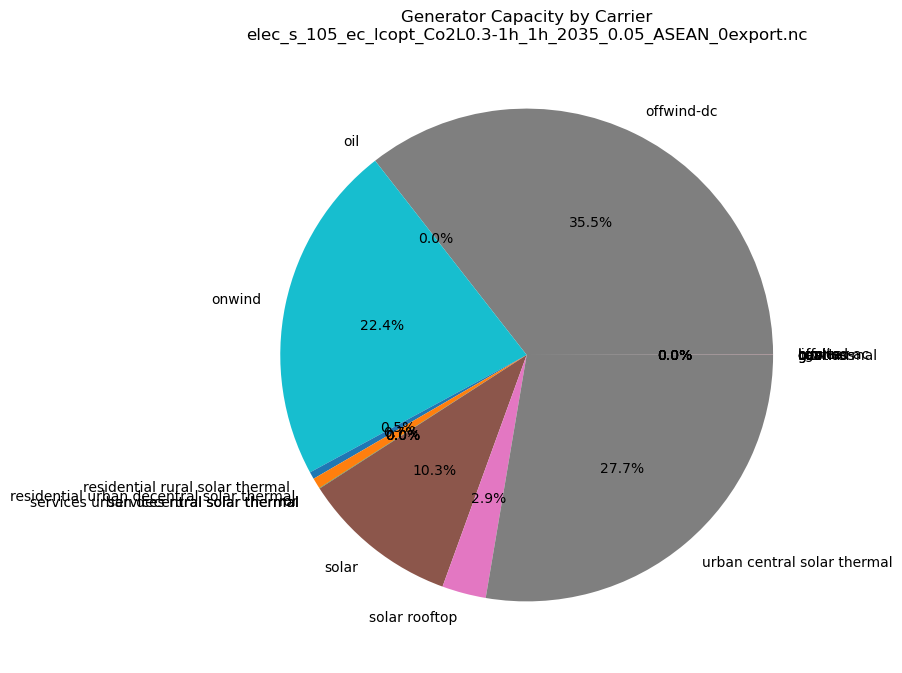


Cross-border links:
                             bus0 country1 carrier        p_nom    p_nom_opt
Link                                                                        
5233                       TH10 0       MY      DC   491.400000   491.415316
5248                       TH10 0       MY      DC   491.400000   491.415487
Plentong - Woodlands        MY0 1       SG      DC   525.000000  1049.999999
Telok Gong – Perawang       MY0 1       ID      DC   600.000000  1199.999998
Kudat – Palawan             MY4 0       PH      DC   196.000000   391.999997
...                           ...      ...     ...          ...          ...
KH0 0 coal-2025        KH0 0 coal       KH    coal  1106.060606  1106.060606
LA0 1 coal-2025        LA0 1 coal       LA    coal  2000.000000  2000.000000
PH1 1 coal-2025        PH1 1 coal       PH    coal  5866.666667  5866.666667
VN0 1 coal-2025        VN0 1 coal       VN    coal  3636.363636  3636.363636
VN0 2 coal-2025        VN0 2 coal       VN    coal  433

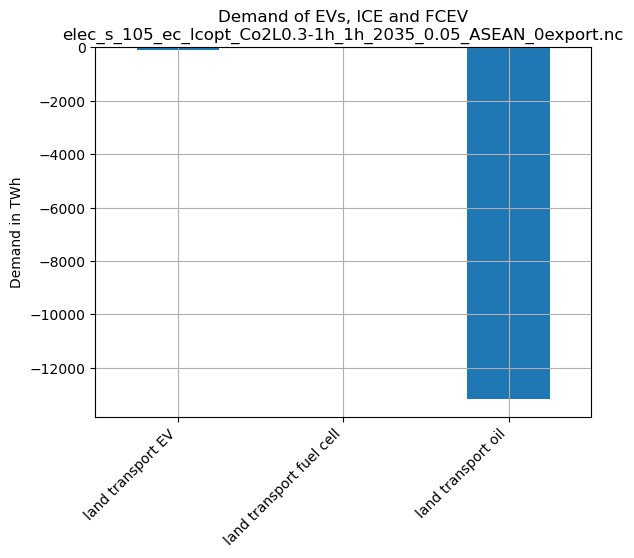

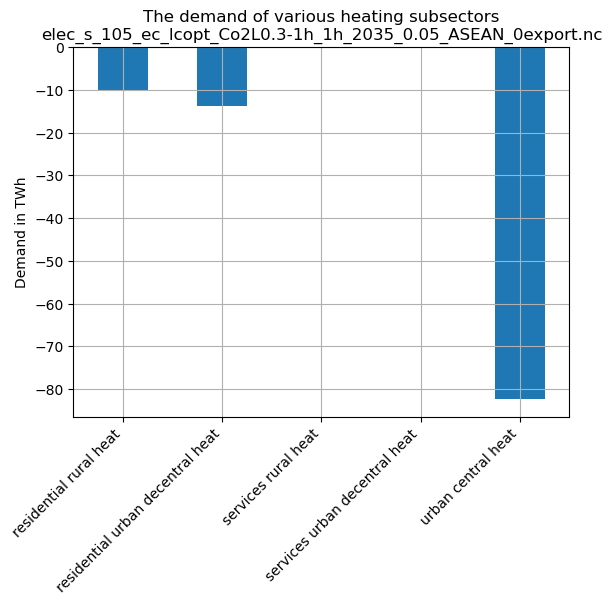

Gas Boiler: 40.12162 MWh
Heat Pump: 1851284.7864400002 MWh
Resistive Heater: 41.28838 MWh
CHP: 20704081819.585968 MWh


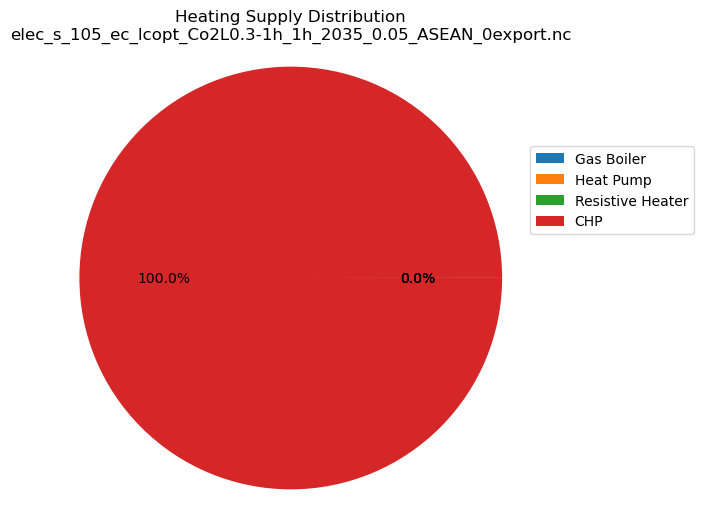

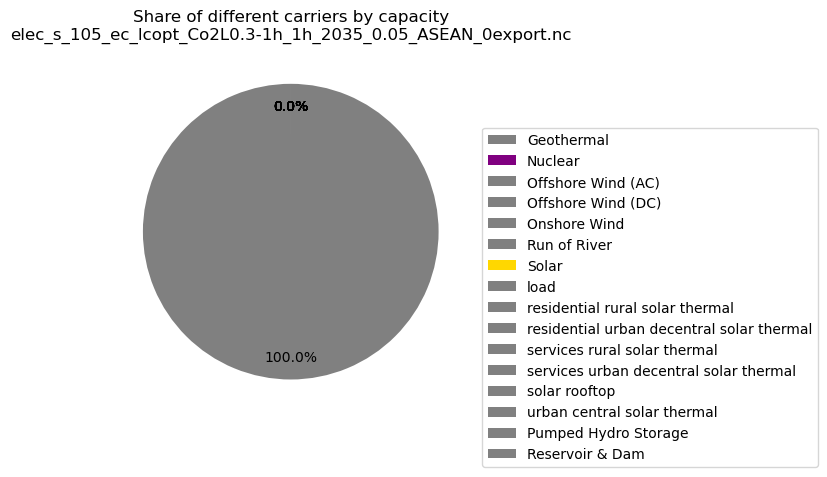

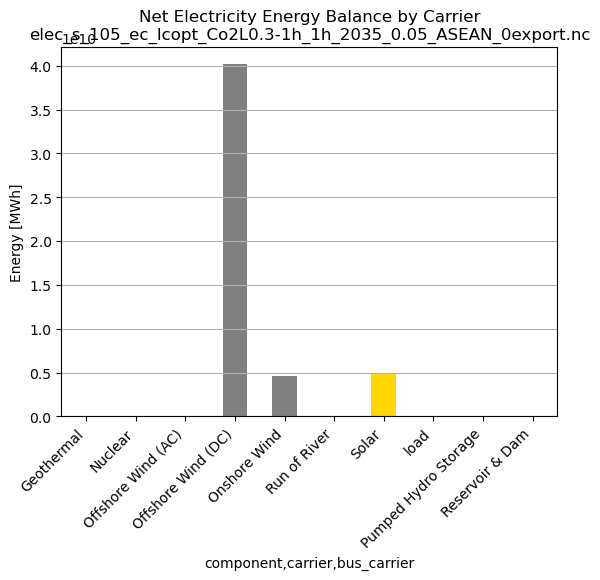


Voronoi p_nom_max density for onwind:
name
1341    0.0
1369    0.0
1518    0.0
1520    0.0
1657    0.0
       ... 
3859    0.0
3860    0.0
3861    0.0
3862    0.0
3863    0.0
Name: p_nom_max, Length: 3018, dtype: float64


c:\Users\ffill\anaconda3\envs\pypsa-earth-plus\lib\site-packages\matplotlib\colors.py:1254: RuntimeWarning:

invalid value encountered in divide

c:\Users\ffill\anaconda3\envs\pypsa-earth-plus\lib\site-packages\matplotlib\colors.py:1254: RuntimeWarning:

invalid value encountered in divide



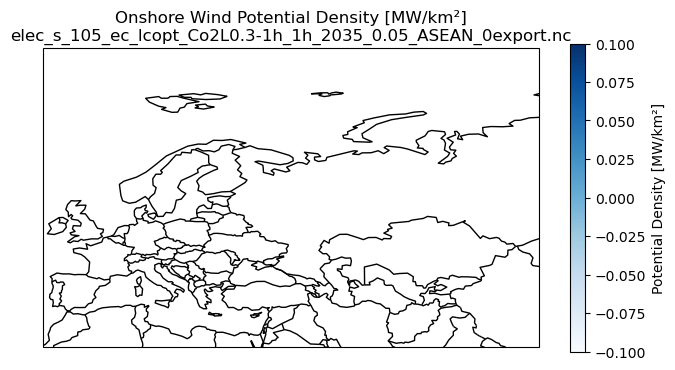


Voronoi p_nom_max density for solar:
name
1341    0.0
1369    0.0
1518    0.0
1520    0.0
1657    0.0
       ... 
3859    0.0
3860    0.0
3861    0.0
3862    0.0
3863    0.0
Name: p_nom_max, Length: 3018, dtype: float64


c:\Users\ffill\anaconda3\envs\pypsa-earth-plus\lib\site-packages\matplotlib\colors.py:1254: RuntimeWarning:

invalid value encountered in divide

c:\Users\ffill\anaconda3\envs\pypsa-earth-plus\lib\site-packages\matplotlib\colors.py:1254: RuntimeWarning:

invalid value encountered in divide



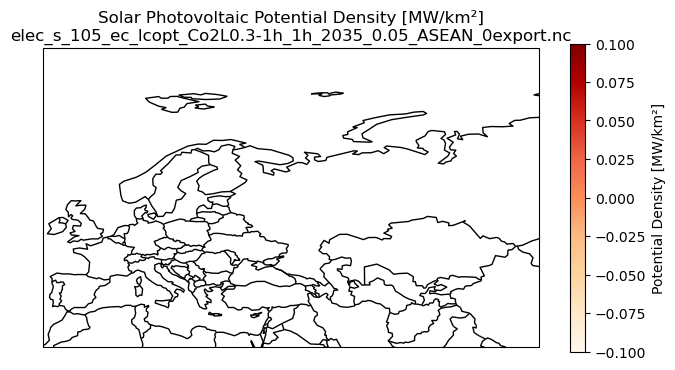

In [12]:
for filename in os.listdir(folder):
    if filename.endswith(".nc"):
        file_path = os.path.join(folder, filename)
        print(f"\n=== Processing file: {filename} ===")

        # Load network
        n = pypsa.Network(file_path)
        print(f"Network loaded from {file_path}")
        print("Name:", n.name)
        print("Meta:", n.meta)
        print("Snapshots:", n.snapshots)

        # -------------------------
        # Installed capacity bar
        # -------------------------
        generator = n.generators.groupby("carrier").p_nom_opt.sum()
        if "load" in generator.index:
            generator = generator.drop("load")
        print("\nInstalled generation capacity by carrier (MW):")
        print(generator)
        generator.plot(kind="bar", color="skyblue")
        plt.ylabel("Installed Capacity [MW]")
        plt.title(f"Installed Generation Capacity by Carrier\n{filename}")
        plt.show()

        # -------------------------
        # Total generation bar
        # -------------------------
        (
            n.generators_t.p
            .multiply(n.generators.p_nom_opt, axis=1)
            .sum()
            .groupby(n.generators.carrier, axis=0)
            .sum()
            .plot(kind="bar", color="orange")
        )
        plt.ylabel("Total Generation [MWh]")
        plt.title(f"Total Generation by Carrier\n{filename}")
        plt.show()

        # -------------------------
        # Load vs renewable time series
        # -------------------------
        renewables = ["solar", "onwind", "offwind-ac", "offwind-dc"]
        renew_gen = n.generators_t.p.loc[:, n.generators.carrier.isin(renewables)].sum(axis=1)
        load = n.loads_t.p_set.sum(axis=1)

        plt.figure(figsize=(12, 4))
        plt.plot(load, label="Total Load")
        plt.plot(renew_gen, label="Total Renewable Generation")
        plt.legend()
        plt.ylabel("Power [MW]")
        plt.title(f"Load vs. Renewable Generation Over Time\n{filename}")
        plt.show()

        # -------------------------
        # Network geographic plot
        # -------------------------
        bus_scale = 6e3
        line_scale = 6e3
        bus_sizes = [100, 1000]
        line_sizes = [100, 1000]

        gen = n.generators[n.generators.carrier != "load"].groupby(["bus", "carrier"]).p_nom.sum()
        sto = n.storage_units.groupby(["bus", "carrier"]).p_nom.sum()
        buses = pd.concat([gen, sto])
        buses = buses.groupby(["bus", "carrier"]).sum()

        carriers = buses.index.get_level_values(1).unique()
        random.seed(0)
        all_colors = list(mcolors.TABLEAU_COLORS.values()) + list(mcolors.CSS4_COLORS.values())
        random.shuffle(all_colors)
        bus_color = dict(zip(carriers, all_colors[:len(carriers)]))

        fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": ccrs.EqualEarth()})

        with plt.rc_context({"patch.linewidth": 0.}):
            n.plot(
                bus_sizes=buses / bus_scale,
                bus_alpha=0.7,
                bus_colors=bus_color,
                line_widths=n.lines.s_nom_opt / line_scale if not n.lines.empty else None,
                link_widths=n.links.p_nom_opt / line_scale if not n.links.empty else None,
                line_colors="teal",
                ax=ax,
                margin=0.2,
                color_geomap=None,
            )

        if not regions_onshore.empty:
            regions_onshore.plot(
                ax=ax,
                facecolor="whitesmoke",
                edgecolor="white",
                aspect="equal",
                transform=ccrs.PlateCarree(),
                linewidth=0,
            )
            ax.set_extent(country_coordinates, crs=ccrs.PlateCarree())

        legend_kwargs = {"loc": "upper left", "frameon": False}
        legend_circles_dict = {"bbox_to_anchor": (1, 0.67), "labelspacing": 2.5, **legend_kwargs}

        add_legend_circles(
            ax,
            [s / bus_scale for s in bus_sizes],
            [f"{s / 1000} GW" for s in bus_sizes],
            legend_kw=legend_circles_dict,
        )
        add_legend_lines(
            ax,
            [s / line_scale for s in line_sizes],
            [f"{s / 1000} GW" for s in line_sizes],
            legend_kw={"bbox_to_anchor": (1, 0.8), **legend_kwargs},
        )
        carrier_labels = {k: k for k in bus_color}
        add_legend_patches(
            ax,
            pd.Series(bus_color),
            pd.Series(carrier_labels),
            legend_kw={"bbox_to_anchor": (1, 0), **legend_kwargs, "loc": "lower left"},
        )
        fig.tight_layout()
        plt.title(f"Network Map\n{filename}")
        plt.show()

        # -------------------------
        # Generator capacity pie
        # -------------------------
        generator_capacity_by_carrier = (
            n.generators[n.generators.carrier != "load"]
            .groupby("carrier")
            .p_nom.sum()
        )
        print("\nGenerator capacity by carrier (GW):")
        print(generator_capacity_by_carrier / 1e3)
        plt.figure(figsize=(8, 8))
        plt.pie(
            generator_capacity_by_carrier,
            labels=generator_capacity_by_carrier.index,
            autopct='%1.1f%%',
        )
        plt.title(f"Generator Capacity by Carrier\n{filename}")
        plt.show()

        # -------------------------
        # Cross-border interconnects
        # -------------------------
        bus_countries = n.buses.country
        links = n.links.copy()
        links["country0"] = links.bus0.map(bus_countries)
        links["country1"] = links.bus1.map(bus_countries)
        cross_border_links = links[links["country0"] != links["country1"]]

        print("\nCross-border links:")
        print(cross_border_links[["bus0", "country1", "carrier", "p_nom", "p_nom_opt"]])

        print("\nCross-border DC links:")
        print(cross_border_links[cross_border_links["carrier"] == "DC"][["country0", "country1", "carrier", "p_nom", "p_nom_opt"]])

        # -------------------------
        # Transport and heating plots
        # -------------------------
        try:
            load_stats = n.statistics.energy_balance(comps=["Load"], aggregate_time="sum")
            transport_stats_GWh = load_stats[load_stats.index.get_level_values('carrier').str.contains(
                'land transport oil(?! emissions)|land transport fuel cell|land transport EV',
                case=True,
                regex=True
            )]
            transport_stats_TWh = transport_stats_GWh / 1_000_000
            ax = transport_stats_TWh.plot.bar(
                title=f"Demand of EVs, ICE and FCEV\n{filename}",
                xlabel="",
                ylabel="Demand in TWh"
            )
            ax.set_xticklabels(transport_stats_TWh.index.get_level_values('carrier'), rotation=45, ha="right")
            ax.grid(True)
            plt.show()
        except Exception as e:
            print(f"Transport stats not available for {filename}: {e}")

        try:
            heating_stats_GWh = load_stats[load_stats.index.get_level_values('carrier').str.contains(
                'heat', case=False)]
            heating_stats_TWh = heating_stats_GWh / 1_000_000
            ax = heating_stats_TWh.plot.bar(
                title=f"The demand of various heating subsectors\n{filename}",
                xlabel="",
                ylabel="Demand in TWh"
            )
            ax.set_xticklabels(heating_stats_TWh.index.get_level_values('carrier'), rotation=45, ha="right")
            ax.grid(True)
            plt.show()

            heating_supply_stats = n.statistics.supply(comps=["Link"], aggregate_time="sum").loc[
                lambda x: x.index.get_level_values('carrier').str.contains('heat|boiler|pump|chp', case=False)
            ]
            heating_types = ['Gas Boiler', 'Heat Pump', 'Resistive Heater', 'CHP']
            heating_sums = [
                heating_supply_stats[heating_supply_stats.index.get_level_values('carrier').str.contains(ht, case=False)].sum()
                for ht in heating_types
            ]
            for ht, sum_value in zip(heating_types, heating_sums):
                print(f"{ht}: {sum_value} MWh")
            plt.figure(figsize=(6, 6))
            plt.pie(heating_sums, autopct='%1.1f%%')
            plt.title(f"Heating Supply Distribution\n{filename}")
            plt.legend(heating_types, loc='upper left', bbox_to_anchor=(1, 0.8))
            plt.axis('equal')
            plt.show()
        except Exception as e:
            print(f"Heating stats not available for {filename}: {e}")

        # -------------------------
        # Electricity capacity pie
        # -------------------------
        capacity_stats = n.statistics.installed_capacity(comps=["Generator"])
        capacity_stats_non_zero = capacity_stats[capacity_stats != 0].dropna()
        capacity_stats_plus = n.statistics.installed_capacity(comps=["StorageUnit"])
        combined_capacity_stats = pd.concat([capacity_stats_non_zero, capacity_stats_plus])
        color_list = color_matching(combined_capacity_stats)

        combined_capacity_stats.plot.pie(
            title=f"Share of different carriers by capacity\n{filename}",
            labels=None,
            autopct='%1.1f%%',
            pctdistance=0.85,
            startangle=90,
            ylabel="",
            colors=color_list,
        )
        custom_labels = combined_capacity_stats.index.get_level_values("carrier")
        plt.legend(custom_labels, loc='upper left', bbox_to_anchor=(1, 0.8))
        plt.show()

        # -------------------------
        # Electricity energy pie
        # -------------------------
        energy_stats = n.statistics.energy_balance(comps=["Generator"])
        electricity_energy_stats = energy_stats[energy_stats.index.get_level_values('bus_carrier') == 'AC']
        electricity_energy_stats_plus = n.statistics.energy_balance(comps=["StorageUnit"])
        combined_electricity_energy_stats = pd.concat([electricity_energy_stats, electricity_energy_stats_plus])
        color_list = color_matching(combined_electricity_energy_stats)

        ax = combined_electricity_energy_stats.plot.bar(
            title=f"Net Electricity Energy Balance by Carrier\n{filename}",
            color=color_list,
        )
        ax.set_ylabel("Energy [MWh]")
        ax.grid(True, axis='y')

        # Rotate labels for clarity
        ax.set_xticklabels(
            combined_electricity_energy_stats.index.get_level_values("carrier"),
            rotation=45,
            ha="right"
        )

        plt.show()

        

        # -------------------------
        # Voronoi plots
        # -------------------------
        warnings.simplefilter(action='ignore', category=FutureWarning)
        plot_voronoi(
            n,
            carrier="onwind",
            voronoi="onshore",
            cmap="Blues",
            projection=ccrs.PlateCarree(),
            title=f"Onshore Wind Potential Density [MW/km²]\n{filename}",
            country_coordinates=country_coordinates,
        )
        plot_voronoi(
            n,
            carrier="solar",
            voronoi="onshore",
            cmap="OrRd",
            projection=ccrs.PlateCarree(),
            title=f"Solar Photovoltaic Potential Density [MW/km²]\n{filename}",
            country_coordinates=country_coordinates,
        )
        warnings.simplefilter(action='default', category=FutureWarning)